<a href="https://colab.research.google.com/github/ipeirotis/dealing_with_data/blob/master/01-Pandas/B2-Data_Cleaning_and_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B2: Data Cleaning and Preparation

## The Reality of Real-World Data

In notebooks A1-A4, we worked with relatively clean datasets. In reality, **80% of a data scientist's time is spent cleaning and preparing data**. Real-world data is messy:

| Problem | Example | Business Impact |
|---------|---------|----------------|
| **Missing values** | Empty cells, "N/A", "Unknown" | Biased analysis, failed calculations |
| **Inconsistent formats** | "NYC", "New York", "new york" | Incorrect grouping, missed matches |
| **Wrong data types** | ZIP codes stored as numbers | Lost leading zeros (07030 → 7030) |
| **Outliers** | Age = 999, Price = -50 | Skewed statistics, wrong conclusions |
| **Duplicates** | Same record entered twice | Inflated counts, double-billing |

This notebook teaches you to:
1. **Diagnose** data quality issues
2. **Handle** missing values strategically
3. **Clean** text and fix inconsistencies
4. **Convert** data types appropriately
5. **Detect** and handle outliers
6. **Validate** your cleaned data

## Learning Objectives

By completing this notebook, you will be able to:
- Assess data quality using `.info()`, `.isna()`, and `.describe()`
- Choose appropriate strategies for handling missing data
- Use string methods to clean text data
- Convert between data types safely
- Identify and handle outliers
- Create reproducible data cleaning pipelines

---

## Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = [10, 4]
sns.set_style("whitegrid")

# Display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print("✓ Setup complete!")

✓ Setup complete!


In [2]:
# Load a messy dataset for practice
# This is NYC 311 Service Requests - real data with real messiness!
url = 'https://data.cityofnewyork.us/resource/erm2-nwe9.csv?$limit=50000'
df = pd.read_csv(url)

print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
df.head()

Loaded 50,000 rows × 41 columns


/tmp/ipython-input-3901457302.py:4: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,67065095,2025-12-06T02:53:07.000,NaN,DSNY,Department of Sanitation,Graffiti,Graffiti,NaN,10467.0,3529 WHITEPLAINS ROAD,WHITEPLAINS ROAD,NaN,NaN,NaN,NaN,ADDRESS,BRONX,NaN,NaN,Open,2026-01-05T02:53:07.000,The graffiti on this property has been schedul...,2025-12-06T02:53:07.000,12 BRONX,2.046430e+09,BRONX,1021300.0,259250.0,UNKNOWN,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.878178,-73.866023,"\n, \n(40.87817786685797, -73.86602282535466)"
1,67066747,2025-12-06T02:51:10.000,NaN,DSNY,Department of Sanitation,Graffiti,Graffiti,Mixed Use,10467.0,3488 WEBSTER AVENUE,WEBSTER AVENUE,NaN,NaN,NaN,NaN,ADDRESS,BRONX,NaN,NaN,Open,2026-01-05T02:51:10.000,The graffiti on this property has been schedul...,2025-12-06T02:51:10.000,07 BRONX,2.033570e+09,BRONX,1019751.0,259364.0,UNKNOWN,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.878497,-73.871624,"\n, \n(40.87849712785142, -73.87162357991)"
2,67068091,2025-12-06T02:06:12.000,NaN,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,10466.0,655 EAST 230 STREET,EAST 230 STREET,CARPENTER AVENUE,LOWERRE PLACE,CARPENTER AVENUE,LOWERRE PLACE,ADDRESS,BRONX,EAST 230 STREET,NaN,In Progress,NaN,NaN,NaN,12 BRONX,2.048330e+09,BRONX,1022911.0,264242.0,MOBILE,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.891872,-73.860168,"\n, \n(40.89187241649303, -73.86016845296459)"
3,67069952,2025-12-06T02:05:54.000,NaN,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,Street/Sidewalk,10033.0,92 PINEHURST AVENUE,PINEHURST AVENUE,WEST 181 STREET,HUDSON VIEW GARDENS,WEST 181 STREET,HUDSON VIEW GARDENS,ADDRESS,NEW YORK,PINEHURST AVENUE,NaN,In Progress,NaN,NaN,NaN,12 MANHATTAN,1.021798e+09,MANHATTAN,1001099.0,249522.0,ONLINE,Unspecified,MANHATTAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.851539,-73.939096,"\n, \n(40.85153914538499, -73.93909644675512)"
4,67068083,2025-12-06T02:05:22.000,NaN,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Store/Commercial,11206.0,894 BROADWAY,BROADWAY,BELVIDERE STREET,ARION PLACE,BELVIDERE STREET,ARION PLACE,ADDRESS,BROOKLYN,BROADWAY,NaN,In Progress,NaN,NaN,NaN,03 BROOKLYN,3.015820e+09,BROOKLYN,1001697.0,193584.0,MOBILE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.698003,-73.937080,"\n, \n(40.69800293380301, -73.93708011114347)"


---

## Part 1: Diagnosing Data Quality Issues

Before cleaning, you need to understand what's wrong. Think of this as a "data health checkup."

### The Data Quality Checklist

1. **Shape**: How many rows and columns?
2. **Types**: Are columns the right data type?
3. **Missing**: How much data is missing?
4. **Values**: Are values reasonable?
5. **Duplicates**: Are there duplicate records?

In [3]:
# Step 1: Basic shape
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 50,000 rows × 41 columns


In [4]:
# Step 2: Data types and missing values overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   unique_key                      50000 non-null  int64  
 1   created_date                    50000 non-null  object 
 2   closed_date                     31791 non-null  object 
 3   agency                          50000 non-null  object 
 4   agency_name                     50000 non-null  object 
 5   complaint_type                  50000 non-null  object 
 6   descriptor                      49325 non-null  object 
 7   location_type                   45682 non-null  object 
 8   incident_zip                    49698 non-null  float64
 9   incident_address                48769 non-null  object 
 10  street_name                     48769 non-null  object 
 11  cross_street_1                  30826 non-null  object 
 12  cross_street_2                  

In [5]:
# Step 3: Detailed missing value analysis
missing = df.isna().sum()
missing_pct = (df.isna().sum() / len(df) * 100).round(1)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Data Type': df.dtypes
})

# Show columns with missing data
missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %,Data Type
taxi_company_borough,49976,100.0,object
road_ramp,49881,99.8,object
facility_type,49914,99.8,object
bridge_highway_direction,49871,99.7,object
bridge_highway_name,49778,99.6,object
bridge_highway_segment,49778,99.6,object
due_date,49699,99.4,object
taxi_pick_up_location,49441,98.9,object
vehicle_type,48286,96.6,object
landmark,22830,45.7,object


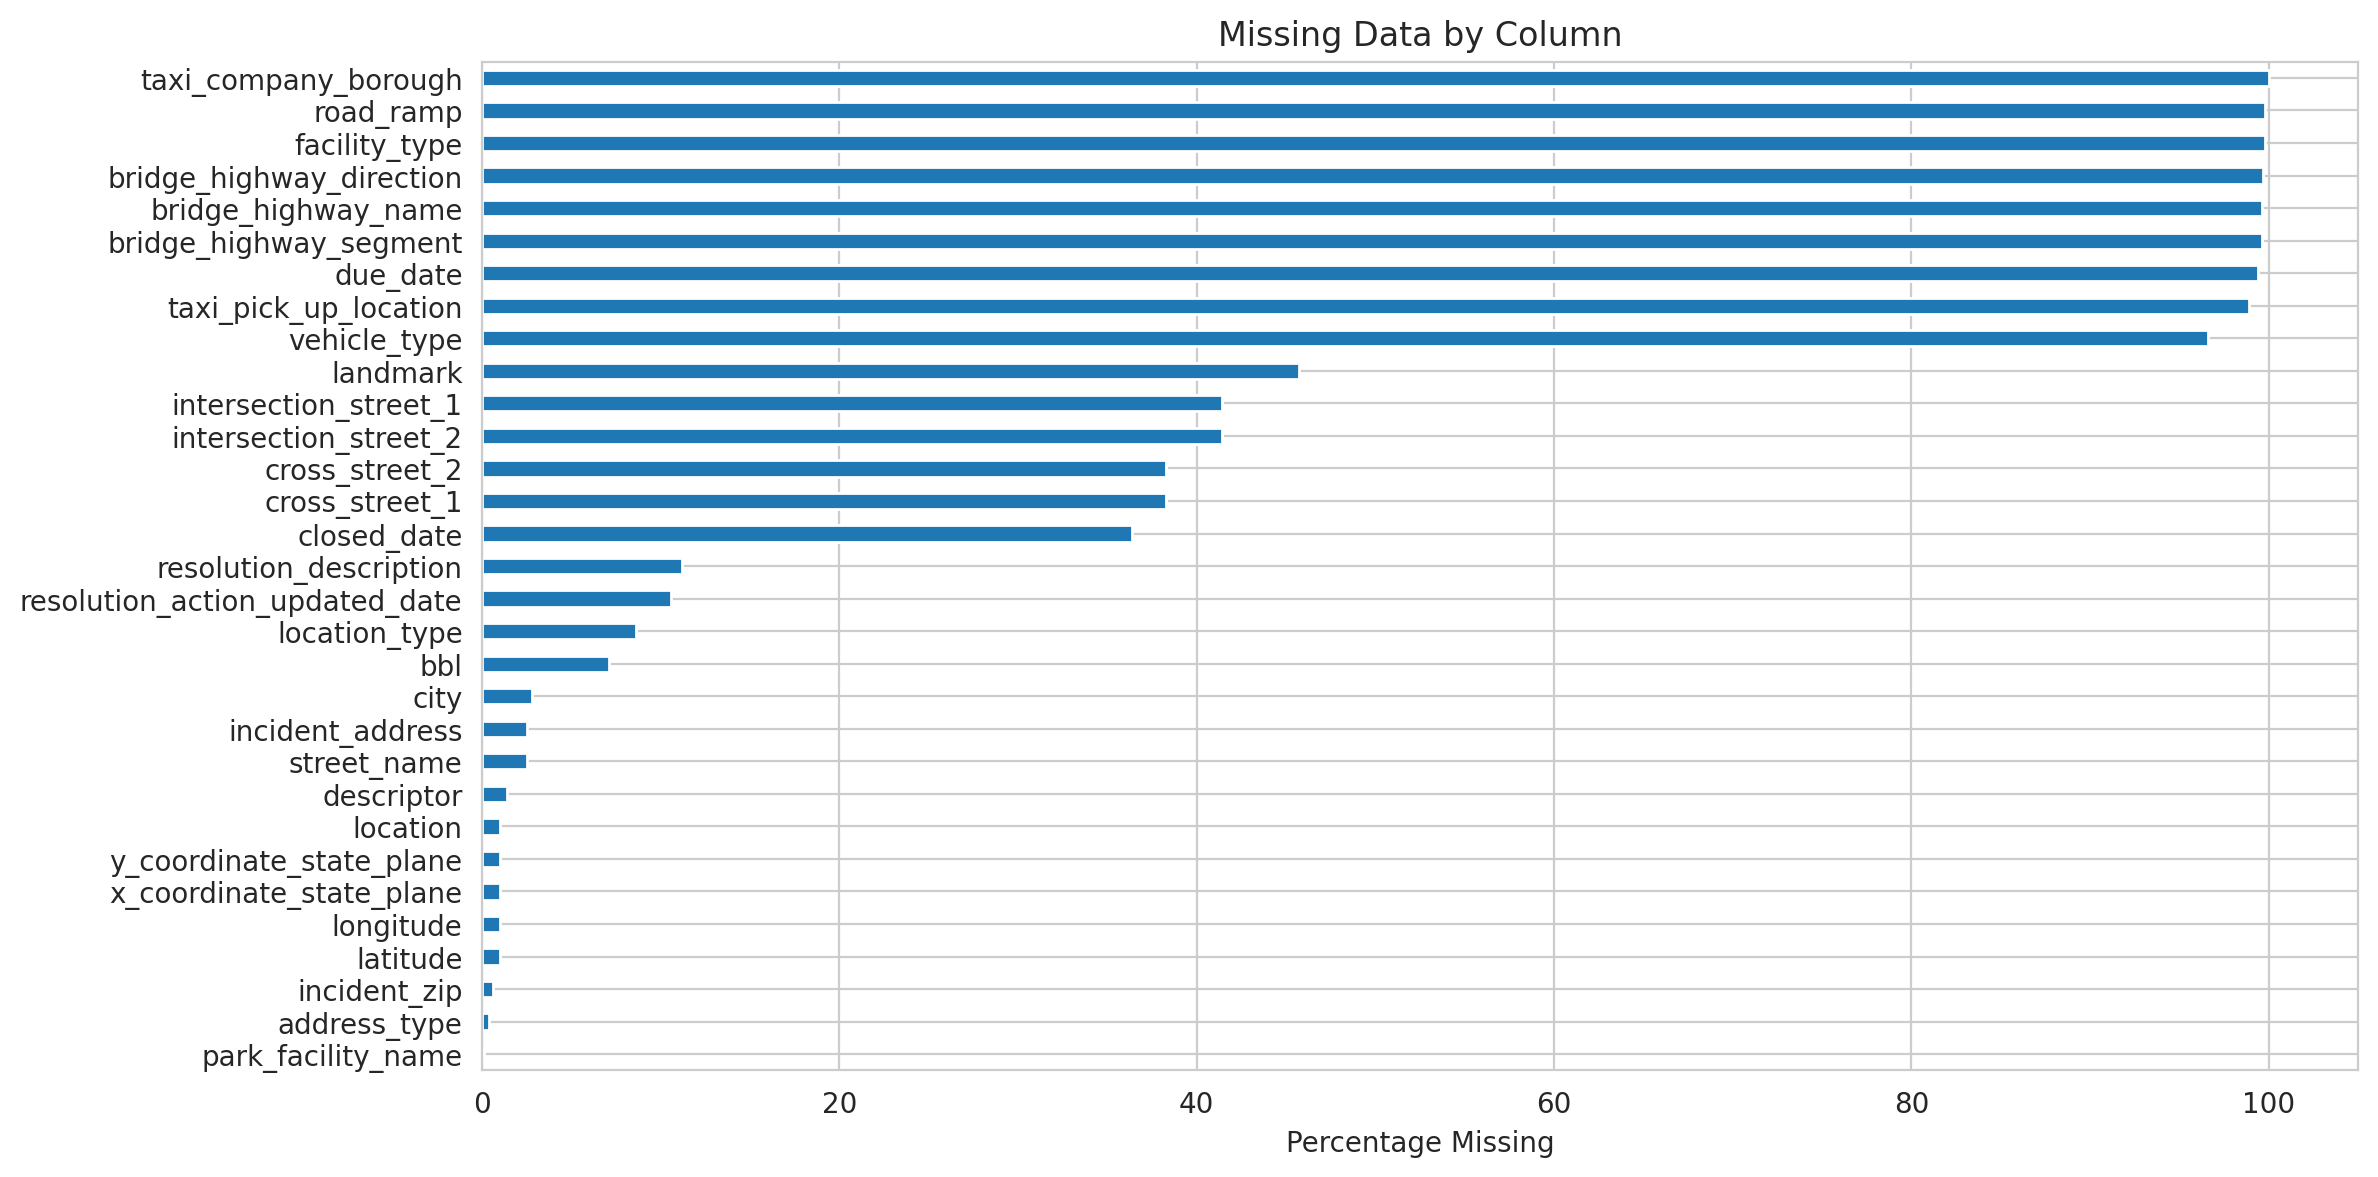

In [6]:
# Visualize missing data patterns
# Only show columns with some missing data
cols_with_missing = missing[missing > 0].index.tolist()

if len(cols_with_missing) > 0:
    plt.figure(figsize=(12, 6))
    missing_pct[cols_with_missing].sort_values(ascending=True).plot(kind='barh')
    plt.xlabel('Percentage Missing')
    plt.title('Missing Data by Column')
    plt.tight_layout()

In [7]:
# Step 4: Check for duplicates
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates:,} ({n_duplicates/len(df)*100:.1f}%)")

# Check duplicates on key column (if there's a unique ID)
if 'unique_key' in df.columns:
    n_dup_keys = df['unique_key'].duplicated().sum()
    print(f"Duplicate unique_key values: {n_dup_keys:,}")

Duplicate rows: 0 (0.0%)
Duplicate unique_key values: 0


In [8]:
# Step 5: Quick look at value distributions for key columns
print("Borough distribution:")
print(df['borough'].value_counts(dropna=False))

print("\nStatus distribution:")
print(df['status'].value_counts(dropna=False))

Borough distribution:
borough
BRONX            17239
BROOKLYN         13227
MANHATTAN         9184
QUEENS            8961
STATEN ISLAND     1361
Unspecified         28
Name: count, dtype: int64

Status distribution:
status
Closed         31136
Open           13465
In Progress     5002
Assigned         182
Started          172
Pending           38
Unspecified        5
Name: count, dtype: int64


### 🎯 Activity 1: Data Quality Assessment

Perform a data quality assessment on the 311 dataset.

**Tasks**:
1. How many columns have more than 50% missing data?
2. What data type is `created_date`? Is this appropriate?
3. Are there any columns that should probably be dropped due to excessive missing data?
4. Look at `complaint_type` — how many unique values are there?

In [9]:
# Activity 1: Your data quality assessment

# 1. Columns with >50% missing:


# 2. Data type of created_date:


# 3. Columns to potentially drop:


# 4. Unique complaint types:



---

## Part 2: Handling Missing Data

Missing data is ubiquitous. The key question is: **Why is it missing?**

| Type | Example | Typical Strategy |
|------|---------|------------------|
| **Missing Completely at Random (MCAR)** | Survey respondent skipped a question by accident | Drop or impute |
| **Missing at Random (MAR)** | Older people less likely to provide email | Impute based on other variables |
| **Missing Not at Random (MNAR)** | High earners don't report income | Requires domain knowledge |

### Strategy 1: Drop Missing Values

In [10]:
# Create a sample dataframe to demonstrate
sample = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Carol', 'David', 'Eve'],
    'age': [25, np.nan, 35, 40, np.nan],
    'salary': [50000, 60000, np.nan, 80000, 55000],
    'department': ['Sales', 'IT', 'IT', np.nan, 'Sales']
})
sample

,name,age,salary,department
0,Alice,25.0,50000.0,Sales
1,Bob,NaN,60000.0,IT
2,Carol,35.0,NaN,IT
3,David,40.0,80000.0,NaN
4,Eve,NaN,55000.0,Sales


In [11]:
# dropna() - remove rows with ANY missing values
sample.dropna()

,name,age,salary,department
0,Alice,25.0,50000.0,Sales


In [12]:
# dropna() with subset - only drop if specific columns are missing
sample.dropna(subset=['age'])

,name,age,salary,department
0,Alice,25.0,50000.0,Sales
2,Carol,35.0,NaN,IT
3,David,40.0,80000.0,NaN


In [13]:
# dropna() with threshold - keep rows with at least n non-null values
sample.dropna(thresh=3)  # Keep rows with at least 3 non-null values

,name,age,salary,department
0,Alice,25.0,50000.0,Sales
1,Bob,NaN,60000.0,IT
2,Carol,35.0,NaN,IT
3,David,40.0,80000.0,NaN
4,Eve,NaN,55000.0,Sales


### Strategy 2: Fill Missing Values

In [14]:
# fillna() with a constant
sample['department'].fillna('Unknown')

,department
0,Sales
1,IT
2,IT
3,Unknown
4,Sales


In [15]:
# fillna() with mean (for numeric columns)
sample['age'].fillna(sample['age'].mean())

,age
0,25.000000
1,33.333333
2,35.000000
3,40.000000
4,33.333333


In [16]:
# fillna() with median (more robust to outliers)
sample['salary'].fillna(sample['salary'].median())

,salary
0,50000.0
1,60000.0
2,57500.0
3,80000.0
4,55000.0


In [17]:
# fillna() with mode (for categorical columns)
sample['department'].fillna(sample['department'].mode()[0])

,department
0,Sales
1,IT
2,IT
3,IT
4,Sales


In [18]:
# Forward fill - use previous value (good for time series)
sample['age'].ffill()

,age
0,25.0
1,25.0
2,35.0
3,40.0
4,40.0


### Strategy 3: Create a Missing Indicator

Sometimes the fact that data is missing is informative!

In [19]:
# Create indicator column before filling
sample_with_indicator = sample.copy()
sample_with_indicator['age_missing'] = sample['age'].isna()
sample_with_indicator['age'] = sample['age'].fillna(sample['age'].median())

sample_with_indicator

,name,age,salary,department,age_missing
0,Alice,25.0,50000.0,Sales,False
1,Bob,35.0,60000.0,IT,True
2,Carol,35.0,NaN,IT,False
3,David,40.0,80000.0,NaN,False
4,Eve,35.0,55000.0,Sales,True


### Choosing the Right Strategy

| Scenario | Recommended Strategy |
|----------|---------------------|
| < 5% missing, random | Drop rows |
| Numeric, symmetric distribution | Fill with mean |
| Numeric, skewed distribution | Fill with median |
| Categorical | Fill with mode or "Unknown" |
| Time series | Forward or backward fill |
| Missingness is meaningful | Create indicator column |
| > 50% missing | Consider dropping the column |

### 🎯 Activity 2: Handle Missing Values in 311 Data

Apply appropriate missing value strategies to the 311 dataset.

**Tasks**:
1. For `borough`: Fill missing values with "Unspecified" (it's categorical)
2. For `latitude` and `longitude`: Drop rows where BOTH are missing
3. Create a cleaned copy of the dataframe with these changes
4. Verify your changes by checking the missing value counts

In [20]:
# Activity 2: Handle missing values

# Create a copy to work with
df_clean = df.copy()

# 1. Fill borough with "Unspecified"


# 2. Drop rows where BOTH lat and lon are missing


# 3. Check your work



---

## Part 3: Cleaning Text Data

Text data is notoriously messy. Common issues include:
- Inconsistent capitalization: "NYC", "nyc", "Nyc"
- Extra whitespace: "  New York  "
- Typos and variations: "Manhatten", "Manhattan"
- Special characters: "Café" vs "Cafe"

### The `.str` Accessor

Pandas provides string methods through the `.str` accessor:

In [21]:
# Sample messy text data
messy_names = pd.Series([
    '  JOHN SMITH  ',
    'jane doe',
    'Bob Johnson',
    '  ALICE WONG',
    'charlie Brown  '
])

print("Original:")
print(messy_names.tolist())

Original:
['  JOHN SMITH  ', 'jane doe', 'Bob Johnson', '  ALICE WONG', 'charlie Brown  ']


In [22]:
# Strip whitespace
print("After strip():")
print(messy_names.str.strip().tolist())

After strip():
['JOHN SMITH', 'jane doe', 'Bob Johnson', 'ALICE WONG', 'charlie Brown']


In [23]:
# Convert case
print("Lower case:")
print(messy_names.str.lower().tolist())

print("\nUpper case:")
print(messy_names.str.upper().tolist())

print("\nTitle case:")
print(messy_names.str.title().tolist())

Lower case:
['  john smith  ', 'jane doe', 'bob johnson', '  alice wong', 'charlie brown  ']

Upper case:
['  JOHN SMITH  ', 'JANE DOE', 'BOB JOHNSON', '  ALICE WONG', 'CHARLIE BROWN  ']

Title case:
['  John Smith  ', 'Jane Doe', 'Bob Johnson', '  Alice Wong', 'Charlie Brown  ']


In [24]:
# Chain operations: strip, then title case
cleaned_names = messy_names.str.strip().str.title()
print("Cleaned (strip + title):")
print(cleaned_names.tolist())

Cleaned (strip + title):
['John Smith', 'Jane Doe', 'Bob Johnson', 'Alice Wong', 'Charlie Brown']


### Finding and Replacing Text

In [25]:
# Sample data with inconsistent values
cities = pd.Series([
    'New York',
    'NYC',
    'new york city',
    'NY',
    'Manhattan, NY',
    'Brooklyn'
])

print("Original:")
print(cities.tolist())

Original:
['New York', 'NYC', 'new york city', 'NY', 'Manhattan, NY', 'Brooklyn']


In [26]:
# Check if string contains a pattern
cities.str.contains('NY', case=False)

,0
0,False
1,True
2,False
3,True
4,True
5,False


In [27]:
# Replace values
cities.str.replace('NYC', 'New York', case=False)

,0
0,New York
1,New York
2,new york city
3,NY
4,"Manhattan, NY"
5,Brooklyn


In [28]:
# Use a dictionary to replace multiple values at once
city_mapping = {
    'NYC': 'New York',
    'new york city': 'New York',
    'NY': 'New York',
}

cities.replace(city_mapping)

,0
0,New York
1,New York
2,New York
3,New York
4,"Manhattan, NY"
5,Brooklyn


### Splitting and Extracting Text

In [29]:
# Sample data with structured text
full_names = pd.Series(['John Smith', 'Jane Doe', 'Bob Johnson Jr.'])

# Split into parts
full_names.str.split(' ')

,0
0,"[John, Smith]"
1,"[Jane, Doe]"
2,"[Bob, Johnson, Jr.]"


In [30]:
# Split and expand into separate columns
full_names.str.split(' ', expand=True)

,0,1,2
0,John,Smith,None
1,Jane,Doe,None
2,Bob,Johnson,Jr.


In [31]:
# Extract first name only
full_names.str.split(' ').str[0]

,0
0,John
1,Jane
2,Bob


In [32]:
# Get string length
full_names.str.len()

,0
0,10
1,8
2,15


### Real Example: Cleaning 311 Complaint Types

In [33]:
# Look at unique complaint types
print(f"Number of unique complaint types: {df['complaint_type'].nunique()}")
print("\nSample complaint types:")
df['complaint_type'].value_counts().head(20)

Number of unique complaint types: 144

Sample complaint types:


,count
complaint_type,
Noise - Residential,10532
HEAT/HOT WATER,9805
Illegal Parking,5829
Blocked Driveway,2082
UNSANITARY CONDITION,1583
PLUMBING,1044
PAINT/PLASTER,880
Street Condition,777
DOOR/WINDOW,764


In [34]:
# Find noise-related complaints (different spellings/variations)
noise_complaints = df[df['complaint_type'].str.contains('Noise', case=False, na=False)]
print(f"Noise complaints: {len(noise_complaints):,}")
print("\nNoise complaint variations:")
noise_complaints['complaint_type'].value_counts()

Noise complaints: 12,805

Noise complaint variations:


,count
complaint_type,
Noise - Residential,10532
Noise,621
Noise - Street/Sidewalk,524
Noise - Commercial,483
Noise - Vehicle,405
Noise - Helicopter,184
Noise - House of Worship,30
Noise - Park,26


In [35]:
# Create a broader category
df_clean = df.copy()
df_clean['complaint_category'] = df_clean['complaint_type'].apply(
    lambda x: 'Noise' if 'noise' in str(x).lower() else
              'Heating' if 'heat' in str(x).lower() else
              'Parking' if 'parking' in str(x).lower() else
              'Other'
)

df_clean['complaint_category'].value_counts()

,count
complaint_category,
Other,21478
Noise,12805
Heating,9857
Parking,5860


### 🎯 Activity 3: Clean Text Data

Practice cleaning text data in the 311 dataset.

**Tasks**:
1. Look at the `agency` column — are there any inconsistencies?
2. Create a standardized version of the `borough` column (all uppercase)
3. Find all complaints that contain "Illegal" in the complaint type
4. Count how many complaints mention "parking" anywhere in the complaint type

In [36]:
# Activity 3: Clean text data

# 1. Check agency column:


# 2. Standardize borough to uppercase:


# 3. Find "Illegal" complaints:


# 4. Count parking-related complaints:



---

## Part 4: Data Type Conversions

Data often comes in the wrong type. Common issues:

| Problem | Example | Solution |
|---------|---------|----------|
| Dates as strings | "2024-01-15" as object | `pd.to_datetime()` |
| Numbers as strings | "1,234" as object | `pd.to_numeric()` |
| IDs as numbers | ZIP code 07030 as int | `astype(str)` |
| Categories as objects | Borough names | `astype('category')` |

### Converting Dates

In [37]:
# Check current type of date column
print(f"Type of created_date: {df['created_date'].dtype}")
print(f"\nSample values:")
print(df['created_date'].head())

Type of created_date: object

Sample values:
0    2025-12-06T02:53:07.000
1    2025-12-06T02:51:10.000
2    2025-12-06T02:06:12.000
3    2025-12-06T02:05:54.000
4    2025-12-06T02:05:22.000
Name: created_date, dtype: object


In [38]:
# Convert to datetime
df_clean = df.copy()
df_clean['created_date'] = pd.to_datetime(df_clean['created_date'])

print(f"Type after conversion: {df_clean['created_date'].dtype}")
print(f"\nNow we can do date operations:")
print(f"Earliest: {df_clean['created_date'].min()}")
print(f"Latest: {df_clean['created_date'].max()}")

Type after conversion: datetime64[ns]

Now we can do date operations:
Earliest: 2025-12-02 04:57:15
Latest: 2025-12-06 02:53:07


In [39]:
# Extract date components
df_clean['year'] = df_clean['created_date'].dt.year
df_clean['month'] = df_clean['created_date'].dt.month
df_clean['day_of_week'] = df_clean['created_date'].dt.day_name()
df_clean['hour'] = df_clean['created_date'].dt.hour

df_clean[['created_date', 'year', 'month', 'day_of_week', 'hour']].head()

,created_date,year,month,day_of_week,hour
0,2025-12-06 02:53:07,2025,12,Saturday,2
1,2025-12-06 02:51:10,2025,12,Saturday,2
2,2025-12-06 02:06:12,2025,12,Saturday,2
3,2025-12-06 02:05:54,2025,12,Saturday,2
4,2025-12-06 02:05:22,2025,12,Saturday,2


### Converting Numbers

In [40]:
# Sample data with numeric strings
amounts = pd.Series(['1,234', '5,678', '999', 'N/A', '2,345'])
print("Original (string):")
print(amounts)

Original (string):
0    1,234
1    5,678
2      999
3      N/A
4    2,345
dtype: object


In [41]:
# Remove commas, then convert
amounts_clean = amounts.str.replace(',', '')
amounts_numeric = pd.to_numeric(amounts_clean, errors='coerce')  # 'coerce' turns invalid values to NaN

print("\nAfter conversion (numeric):")
print(amounts_numeric)
print(f"\nSum: {amounts_numeric.sum()}")


After conversion (numeric):
0    1234.0
1    5678.0
2     999.0
3       NaN
4    2345.0
dtype: float64

Sum: 10256.0


### Using Categories for Efficiency

In [42]:
# Check memory usage before
print("Memory usage before:")
print(df['borough'].memory_usage(deep=True))

Memory usage before:
2796566


In [43]:
# Convert to category
df_clean['borough'] = df['borough'].astype('category')

print("Memory usage after category conversion:")
print(df_clean['borough'].memory_usage(deep=True))

print(f"\nCategories: {df_clean['borough'].cat.categories.tolist()}")

Memory usage after category conversion:
50650

Categories: ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND', 'Unspecified']


### 🎯 Activity 4: Fix Data Types

Fix data types in the 311 dataset.

**Tasks**:
1. Convert `created_date` and `closed_date` to datetime
2. Calculate how long each complaint took to resolve (closed_date - created_date)
3. Convert `borough` to a category type
4. What's the average resolution time by borough?

In [44]:
# Activity 4: Fix data types

df_clean = df.copy()

# 1. Convert dates:


# 2. Calculate resolution time:


# 3. Convert borough to category:


# 4. Average resolution time by borough:



---

## Part 5: Detecting and Handling Outliers

Outliers are extreme values that may be:
- **Data errors**: Age = 999, Price = -50
- **Genuine extremes**: CEO salary vs. average employee

The approach depends on whether outliers are errors or real data.

### Method 1: Visual Detection

In [45]:
# Create sample data with outliers
np.random.seed(42)
sales = pd.DataFrame({
    'amount': np.concatenate([
        np.random.normal(100, 20, 95),  # Normal sales
        np.array([500, -50, 1000, 5, 800])  # Outliers
    ])
})

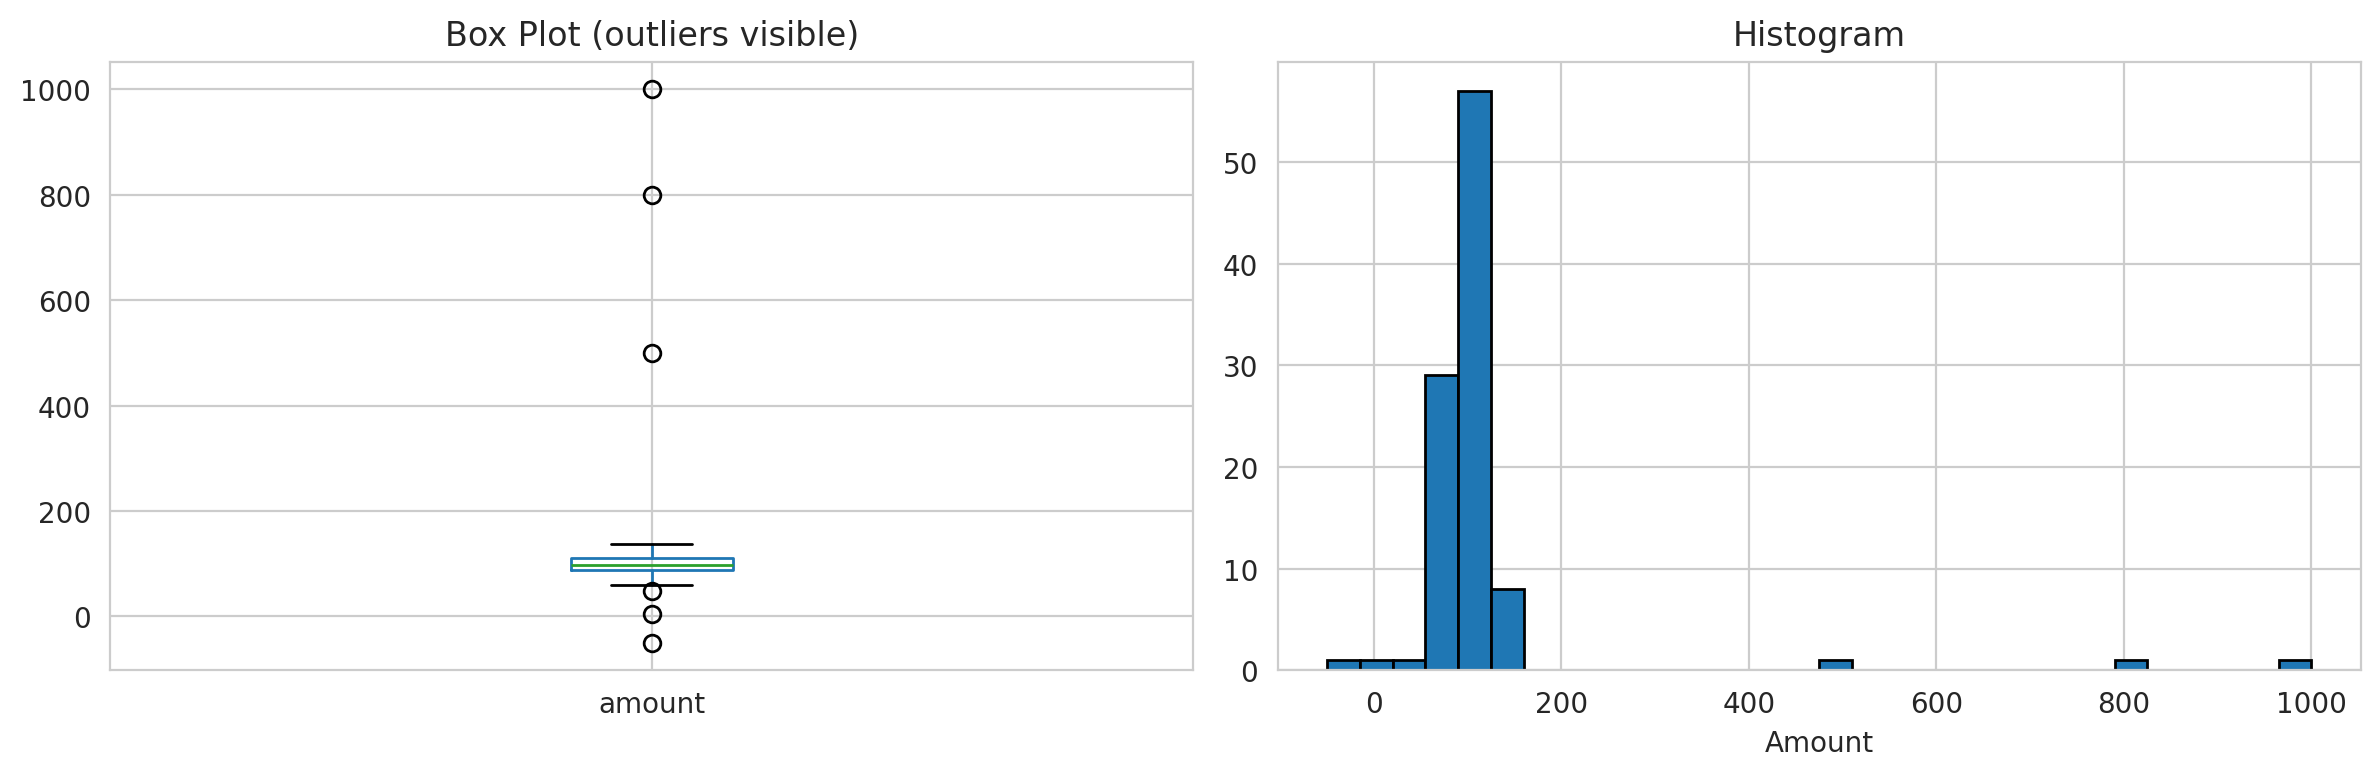

In [46]:
# Box plot - outliers shown as individual points
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot
sales.boxplot(column='amount', ax=axes[0])
axes[0].set_title('Box Plot (outliers visible)')

# Histogram
sales['amount'].hist(bins=30, ax=axes[1], edgecolor='black')
axes[1].set_title('Histogram')
axes[1].set_xlabel('Amount')

plt.tight_layout()

### Method 2: Statistical Detection (IQR Method)

In [47]:
# IQR (Interquartile Range) method
Q1 = sales['amount'].quantile(0.25)
Q3 = sales['amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"\nOutlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")

Q1: 87.75
Q3: 111.20
IQR: 23.45

Outlier bounds: [52.58, 146.37]


In [48]:
# Identify outliers
outliers = sales[(sales['amount'] < lower_bound) | (sales['amount'] > upper_bound)]
print(f"Found {len(outliers)} outliers:")
print(outliers)

Found 6 outliers:
         amount
74    47.605098
95   500.000000
96   -50.000000
97  1000.000000
98     5.000000
99   800.000000


### Method 3: Z-Score Method

In [49]:
# Z-score: how many standard deviations from mean
from scipy import stats

sales['z_score'] = np.abs(stats.zscore(sales['amount']))

# Values with z-score > 3 are typically considered outliers
outliers_zscore = sales[sales['z_score'] > 3]
print(f"Outliers (z-score > 3):")
print(outliers_zscore)

Outliers (z-score > 3):
    amount   z_score
95   500.0  3.138813
97  1000.0  7.222622
99   800.0  5.589098


### Handling Outliers

In [50]:
# Option 1: Remove outliers
sales_no_outliers = sales[(sales['amount'] >= lower_bound) & (sales['amount'] <= upper_bound)]
print(f"Original rows: {len(sales)}")
print(f"After removing outliers: {len(sales_no_outliers)}")

Original rows: 100
After removing outliers: 94


In [51]:
# Option 2: Cap outliers (winsorizing)
sales_capped = sales.copy()
sales_capped['amount'] = sales_capped['amount'].clip(lower=lower_bound, upper=upper_bound)

print("Before capping:")
print(sales['amount'].describe())
print("\nAfter capping:")
print(sales_capped['amount'].describe())

Before capping:
count     100.000000
mean      115.700232
std       123.051538
min       -50.000000
25%        87.748802
50%        97.460874
75%       111.196782
max      1000.000000
Name: amount, dtype: float64

After capping:
count    100.000000
mean      98.642549
std       20.699560
min       52.576832
25%       87.748802
50%       97.460874
75%      111.196782
max      146.368752
Name: amount, dtype: float64


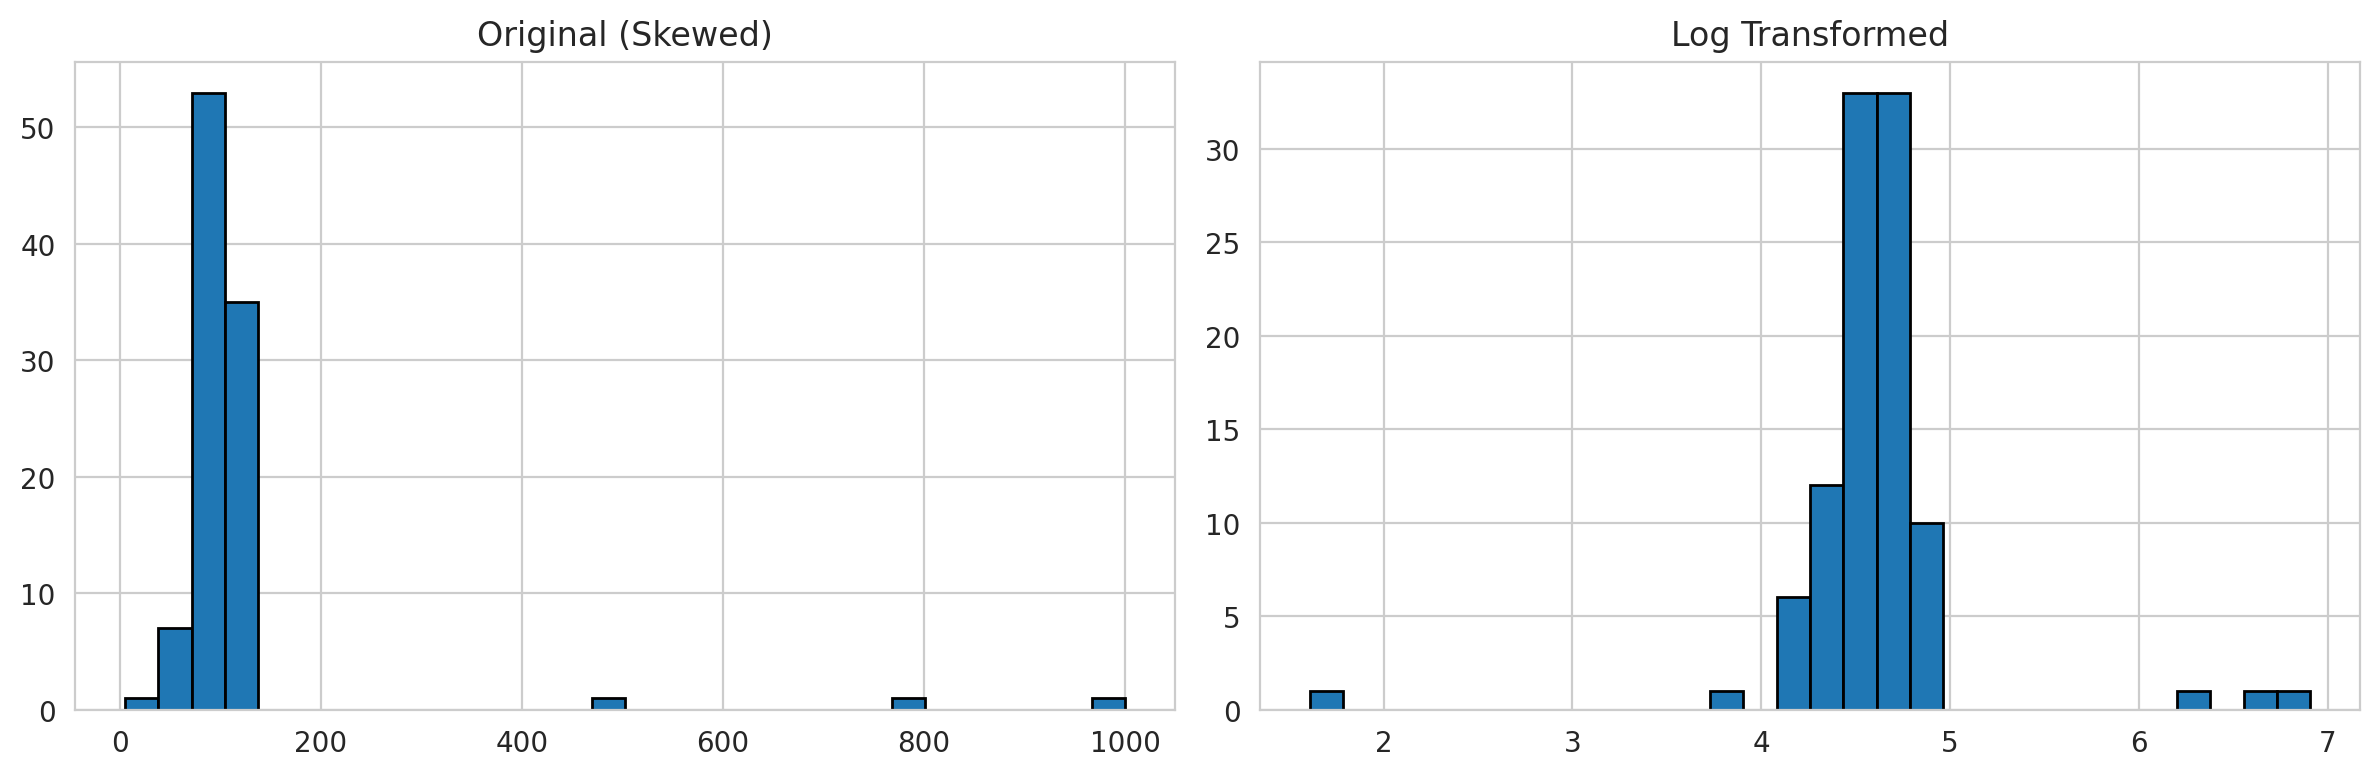

In [52]:
# Option 3: Transform (log transformation for right-skewed data)
# Note: Can't log negative values, so filter first
sales_positive = sales[sales['amount'] > 0].copy()
sales_positive['log_amount'] = np.log(sales_positive['amount'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sales_positive['amount'].hist(bins=30, ax=axes[0], edgecolor='black')
axes[0].set_title('Original (Skewed)')

sales_positive['log_amount'].hist(bins=30, ax=axes[1], edgecolor='black')
axes[1].set_title('Log Transformed')

plt.tight_layout()

### 🎯 Activity 5: Detect Outliers in Geographic Data

The 311 data has latitude and longitude. Let's find geographic outliers!

**Tasks**:
1. Check the range of latitude and longitude values
2. NYC coordinates should be roughly: Latitude 40.5-41.0, Longitude -74.3 to -73.7
3. How many records have coordinates outside NYC?
4. Create a scatter plot of the coordinates to visualize outliers

In [53]:
# Activity 5: Geographic outliers

# 1. Check coordinate ranges:


# 2. Define NYC bounds:
nyc_lat_min, nyc_lat_max = 40.5, 41.0
nyc_lon_min, nyc_lon_max = -74.3, -73.7

# 3. Find outliers:


# 4. Visualize:



---

## Part 6: Data Validation

After cleaning, you should validate that your data makes sense.

### Common Validation Checks

In [54]:
# Create a cleaned dataset
df_clean = df.copy()

# Apply our cleaning steps
df_clean['created_date'] = pd.to_datetime(df_clean['created_date'])
df_clean['closed_date'] = pd.to_datetime(df_clean['closed_date'])
df_clean['borough'] = df_clean['borough'].fillna('Unspecified')
df_clean['borough'] = df_clean['borough'].str.upper()

print("✓ Cleaning applied")

✓ Cleaning applied


In [55]:
# Validation 1: Check for remaining missing values in key columns
key_columns = ['unique_key', 'created_date', 'complaint_type', 'borough']
missing_in_key = df_clean[key_columns].isna().sum()

print("Missing values in key columns:")
print(missing_in_key)

assert missing_in_key.sum() == 0, "Still have missing values in key columns!"

Missing values in key columns:
unique_key        0
created_date      0
complaint_type    0
borough           0
dtype: int64


In [56]:
# Validation 2: Check date ranges make sense
print(f"Date range: {df_clean['created_date'].min()} to {df_clean['created_date'].max()}")

# Check for future dates
future_dates = df_clean[df_clean['created_date'] > pd.Timestamp.now()]
print(f"Records with future dates: {len(future_dates)}")

Date range: 2025-12-02 04:57:15 to 2025-12-06 02:53:07
Records with future dates: 0


In [57]:
# Validation 3: Check categorical values are expected
expected_boroughs = ['MANHATTAN', 'BROOKLYN', 'QUEENS', 'BRONX', 'STATEN ISLAND', 'UNSPECIFIED']
actual_boroughs = df_clean['borough'].unique()

unexpected = set(actual_boroughs) - set(expected_boroughs)
if unexpected:
    print(f"⚠️ Unexpected borough values: {unexpected}")
else:
    print("✓ All borough values are expected")

✓ All borough values are expected


In [58]:
# Validation 4: Check no duplicate unique_keys
duplicates = df_clean['unique_key'].duplicated().sum()
print(f"Duplicate unique_key values: {duplicates}")

if duplicates > 0:
    print("⚠️ Warning: Found duplicates!")

Duplicate unique_key values: 0


In [59]:
# Validation 5: Summary statistics should be reasonable
print("Summary of cleaned data:")
print(f"  Total records: {len(df_clean):,}")
print(f"  Date range: {df_clean['created_date'].min().date()} to {df_clean['created_date'].max().date()}")
print(f"  Unique complaint types: {df_clean['complaint_type'].nunique()}")
print(f"\nRecords by borough:")
print(df_clean['borough'].value_counts())

Summary of cleaned data:
  Total records: 50,000
  Date range: 2025-12-02 to 2025-12-06
  Unique complaint types: 144

Records by borough:
borough
BRONX            17239
BROOKLYN         13227
MANHATTAN         9184
QUEENS            8961
STATEN ISLAND     1361
UNSPECIFIED         28
Name: count, dtype: int64


---

## Part 7: Creating a Cleaning Pipeline

For reproducibility, put all cleaning steps into a function:

In [60]:
def clean_311_data(df):
    """
    Clean NYC 311 Service Request data.

    Steps:
    1. Convert date columns to datetime
    2. Standardize borough names
    3. Handle missing values
    4. Remove geographic outliers
    5. Create derived columns

    Returns:
        Cleaned DataFrame
    """
    # Work on a copy
    df_clean = df.copy()

    # 1. Convert dates
    df_clean['created_date'] = pd.to_datetime(df_clean['created_date'])
    df_clean['closed_date'] = pd.to_datetime(df_clean['closed_date'])

    # 2. Standardize borough
    df_clean['borough'] = df_clean['borough'].fillna('Unspecified').str.upper().str.strip()

    # 3. Handle missing coordinates
    df_clean = df_clean.dropna(subset=['latitude', 'longitude'], how='all')

    # 4. Remove geographic outliers (outside NYC bounds)
    nyc_bounds = (
        (df_clean['latitude'].between(40.5, 41.0) | df_clean['latitude'].isna()) &
        (df_clean['longitude'].between(-74.3, -73.7) | df_clean['longitude'].isna())
    )
    df_clean = df_clean[nyc_bounds]

    # 5. Create derived columns
    df_clean['resolution_time'] = df_clean['closed_date'] - df_clean['created_date']
    df_clean['year'] = df_clean['created_date'].dt.year
    df_clean['month'] = df_clean['created_date'].dt.month
    df_clean['day_of_week'] = df_clean['created_date'].dt.day_name()
    df_clean['hour'] = df_clean['created_date'].dt.hour

    return df_clean

# Apply the cleaning pipeline
df_cleaned = clean_311_data(df)

print(f"Original: {len(df):,} rows")
print(f"Cleaned: {len(df_cleaned):,} rows")
print(f"Removed: {len(df) - len(df_cleaned):,} rows ({(len(df) - len(df_cleaned))/len(df)*100:.1f}%)")

Original: 50,000 rows
Cleaned: 49,509 rows
Removed: 491 rows (1.0%)


In [61]:
# Verify the cleaned data
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49509 entries, 0 to 49999
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype          
---  ------                          --------------  -----          
 0   unique_key                      49509 non-null  int64          
 1   created_date                    49509 non-null  datetime64[ns] 
 2   closed_date                     31493 non-null  datetime64[ns] 
 3   agency                          49509 non-null  object         
 4   agency_name                     49509 non-null  object         
 5   complaint_type                  49509 non-null  object         
 6   descriptor                      48848 non-null  object         
 7   location_type                   45459 non-null  object         
 8   incident_zip                    49381 non-null  float64        
 9   incident_address                48422 non-null  object         
 10  street_name                     48422 non-null  object         

In [62]:
# Now we can do analysis!
print("Complaints by day of week:")
print(df_cleaned['day_of_week'].value_counts())

Complaints by day of week:
day_of_week
Friday       12905
Thursday     12679
Wednesday    12291
Tuesday      10971
Saturday       663
Name: count, dtype: int64


---

## 📝 Activity Solutions

In [63]:
# =============================================================================
# SOLUTION: Activity 1 - Data Quality Assessment
# =============================================================================

# 1. Columns with >50% missing
missing_pct = (df.isna().sum() / len(df) * 100)
cols_over_50 = missing_pct[missing_pct > 50]
print(f"Columns with >50% missing: {len(cols_over_50)}")
print(cols_over_50)

# 2. Data type of created_date
print(f"\nData type of created_date: {df['created_date'].dtype}")
print("Should be datetime, not object!")

# 3. Columns to potentially drop
print(f"\nConsider dropping these columns (>50% missing):")
print(cols_over_50.index.tolist())

# 4. Unique complaint types
print(f"\nUnique complaint types: {df['complaint_type'].nunique()}")

Columns with >50% missing: 9
facility_type               99.828
due_date                    99.398
vehicle_type                96.572
taxi_company_borough        99.952
taxi_pick_up_location       98.882
bridge_highway_name         99.556
bridge_highway_direction    99.742
road_ramp                   99.762
bridge_highway_segment      99.556
dtype: float64

Data type of created_date: object
Should be datetime, not object!

Consider dropping these columns (>50% missing):
['facility_type', 'due_date', 'vehicle_type', 'taxi_company_borough', 'taxi_pick_up_location', 'bridge_highway_name', 'bridge_highway_direction', 'road_ramp', 'bridge_highway_segment']

Unique complaint types: 144


In [64]:
# =============================================================================
# SOLUTION: Activity 2 - Handle Missing Values
# =============================================================================

df_clean = df.copy()

# 1. Fill borough with "Unspecified"
print(f"Borough missing before: {df_clean['borough'].isna().sum()}")
df_clean['borough'] = df_clean['borough'].fillna('Unspecified')
print(f"Borough missing after: {df_clean['borough'].isna().sum()}")

# 2. Drop rows where BOTH lat and lon are missing
print(f"\nRows before: {len(df_clean)}")
df_clean = df_clean.dropna(subset=['latitude', 'longitude'], how='all')
print(f"Rows after dropping where both lat/lon missing: {len(df_clean)}")

# 3. Check your work
print(f"\nMissing value summary:")
print(df_clean[['borough', 'latitude', 'longitude']].isna().sum())

Borough missing before: 0
Borough missing after: 0

Rows before: 50000
Rows after dropping where both lat/lon missing: 49510

Missing value summary:
borough      0
latitude     0
longitude    0
dtype: int64


In [65]:
# =============================================================================
# SOLUTION: Activity 3 - Clean Text Data
# =============================================================================

# 1. Check agency column
print("Agency values:")
print(df['agency'].value_counts().head(10))
print("\n(Agencies look clean - all uppercase abbreviations)")

# 2. Standardize borough to uppercase
df_clean = df.copy()
df_clean['borough_upper'] = df_clean['borough'].str.upper()
print("\nBorough (uppercase):")
print(df_clean['borough_upper'].value_counts())

# 3. Find "Illegal" complaints
illegal = df[df['complaint_type'].str.contains('Illegal', case=False, na=False)]
print(f"\nComplaints with 'Illegal': {len(illegal)}")
print(illegal['complaint_type'].value_counts())

# 4. Count parking-related complaints
parking = df[df['complaint_type'].str.contains('parking', case=False, na=False)]
print(f"\nParking-related complaints: {len(parking)}")

Agency values:
agency
NYPD     21921
HPD      16712
DSNY      3197
DOT       2453
DEP       1973
DOB        840
DOHMH      827
DPR        664
TLC        565
DHS        391
Name: count, dtype: int64

(Agencies look clean - all uppercase abbreviations)

Borough (uppercase):
borough_upper
BRONX            17239
BROOKLYN         13227
MANHATTAN         9184
QUEENS            8961
STATEN ISLAND     1361
UNSPECIFIED         28
Name: count, dtype: int64

Complaints with 'Illegal': 6255
complaint_type
Illegal Parking               5829
Illegal Dumping                352
Illegal Tree Damage             37
Illegal Posting                 31
Illegal Animal Kept as Pet       4
Illegal Animal Sold              1
Illegal Fireworks                1
Name: count, dtype: int64

Parking-related complaints: 5860


In [66]:
# =============================================================================
# SOLUTION: Activity 4 - Fix Data Types
# =============================================================================

df_clean = df.copy()

# 1. Convert dates
df_clean['created_date'] = pd.to_datetime(df_clean['created_date'])
df_clean['closed_date'] = pd.to_datetime(df_clean['closed_date'])
print(f"created_date type: {df_clean['created_date'].dtype}")
print(f"closed_date type: {df_clean['closed_date'].dtype}")

# 2. Calculate resolution time
df_clean['resolution_time'] = df_clean['closed_date'] - df_clean['created_date']
print(f"\nResolution time stats:")
print(df_clean['resolution_time'].describe())

# 3. Convert borough to category
df_clean['borough'] = df_clean['borough'].astype('category')
print(f"\nBorough type: {df_clean['borough'].dtype}")

# 4. Average resolution time by borough
print("\nAverage resolution time by borough:")
avg_resolution = df_clean.groupby('borough', observed=False)['resolution_time'].mean()
print(avg_resolution.sort_values())

created_date type: datetime64[ns]
closed_date type: datetime64[ns]

Resolution time stats:
count                        31791
mean     0 days 09:41:38.915793778
std      0 days 15:33:19.727789395
min              -7 days +21:43:00
25%                0 days 00:44:08
50%                0 days 02:23:46
75%                0 days 10:59:35
max                3 days 15:03:22
Name: resolution_time, dtype: object

Borough type: category

Average resolution time by borough:
borough
BRONX           0 days 08:22:47.253086419
QUEENS          0 days 09:14:22.796259842
BROOKLYN        0 days 10:47:11.006382701
MANHATTAN       0 days 11:10:34.539723320
STATEN ISLAND   0 days 13:12:26.060075093
Unspecified     0 days 15:02:56.888888888
Name: resolution_time, dtype: timedelta64[ns]


Latitude range:
count    49510.000000
mean        40.762941
std          0.096350
min         40.499850
25%         40.681601
50%         40.756909
75%         40.852984
max         40.912869
Name: latitude, dtype: float64

Longitude range:
count    49510.000000
mean       -73.913329
std          0.070551
min        -74.250847
25%        -73.957025
50%        -73.911796
75%        -73.860168
max        -73.701308
Name: longitude, dtype: float64

Records outside NYC bounds: 1


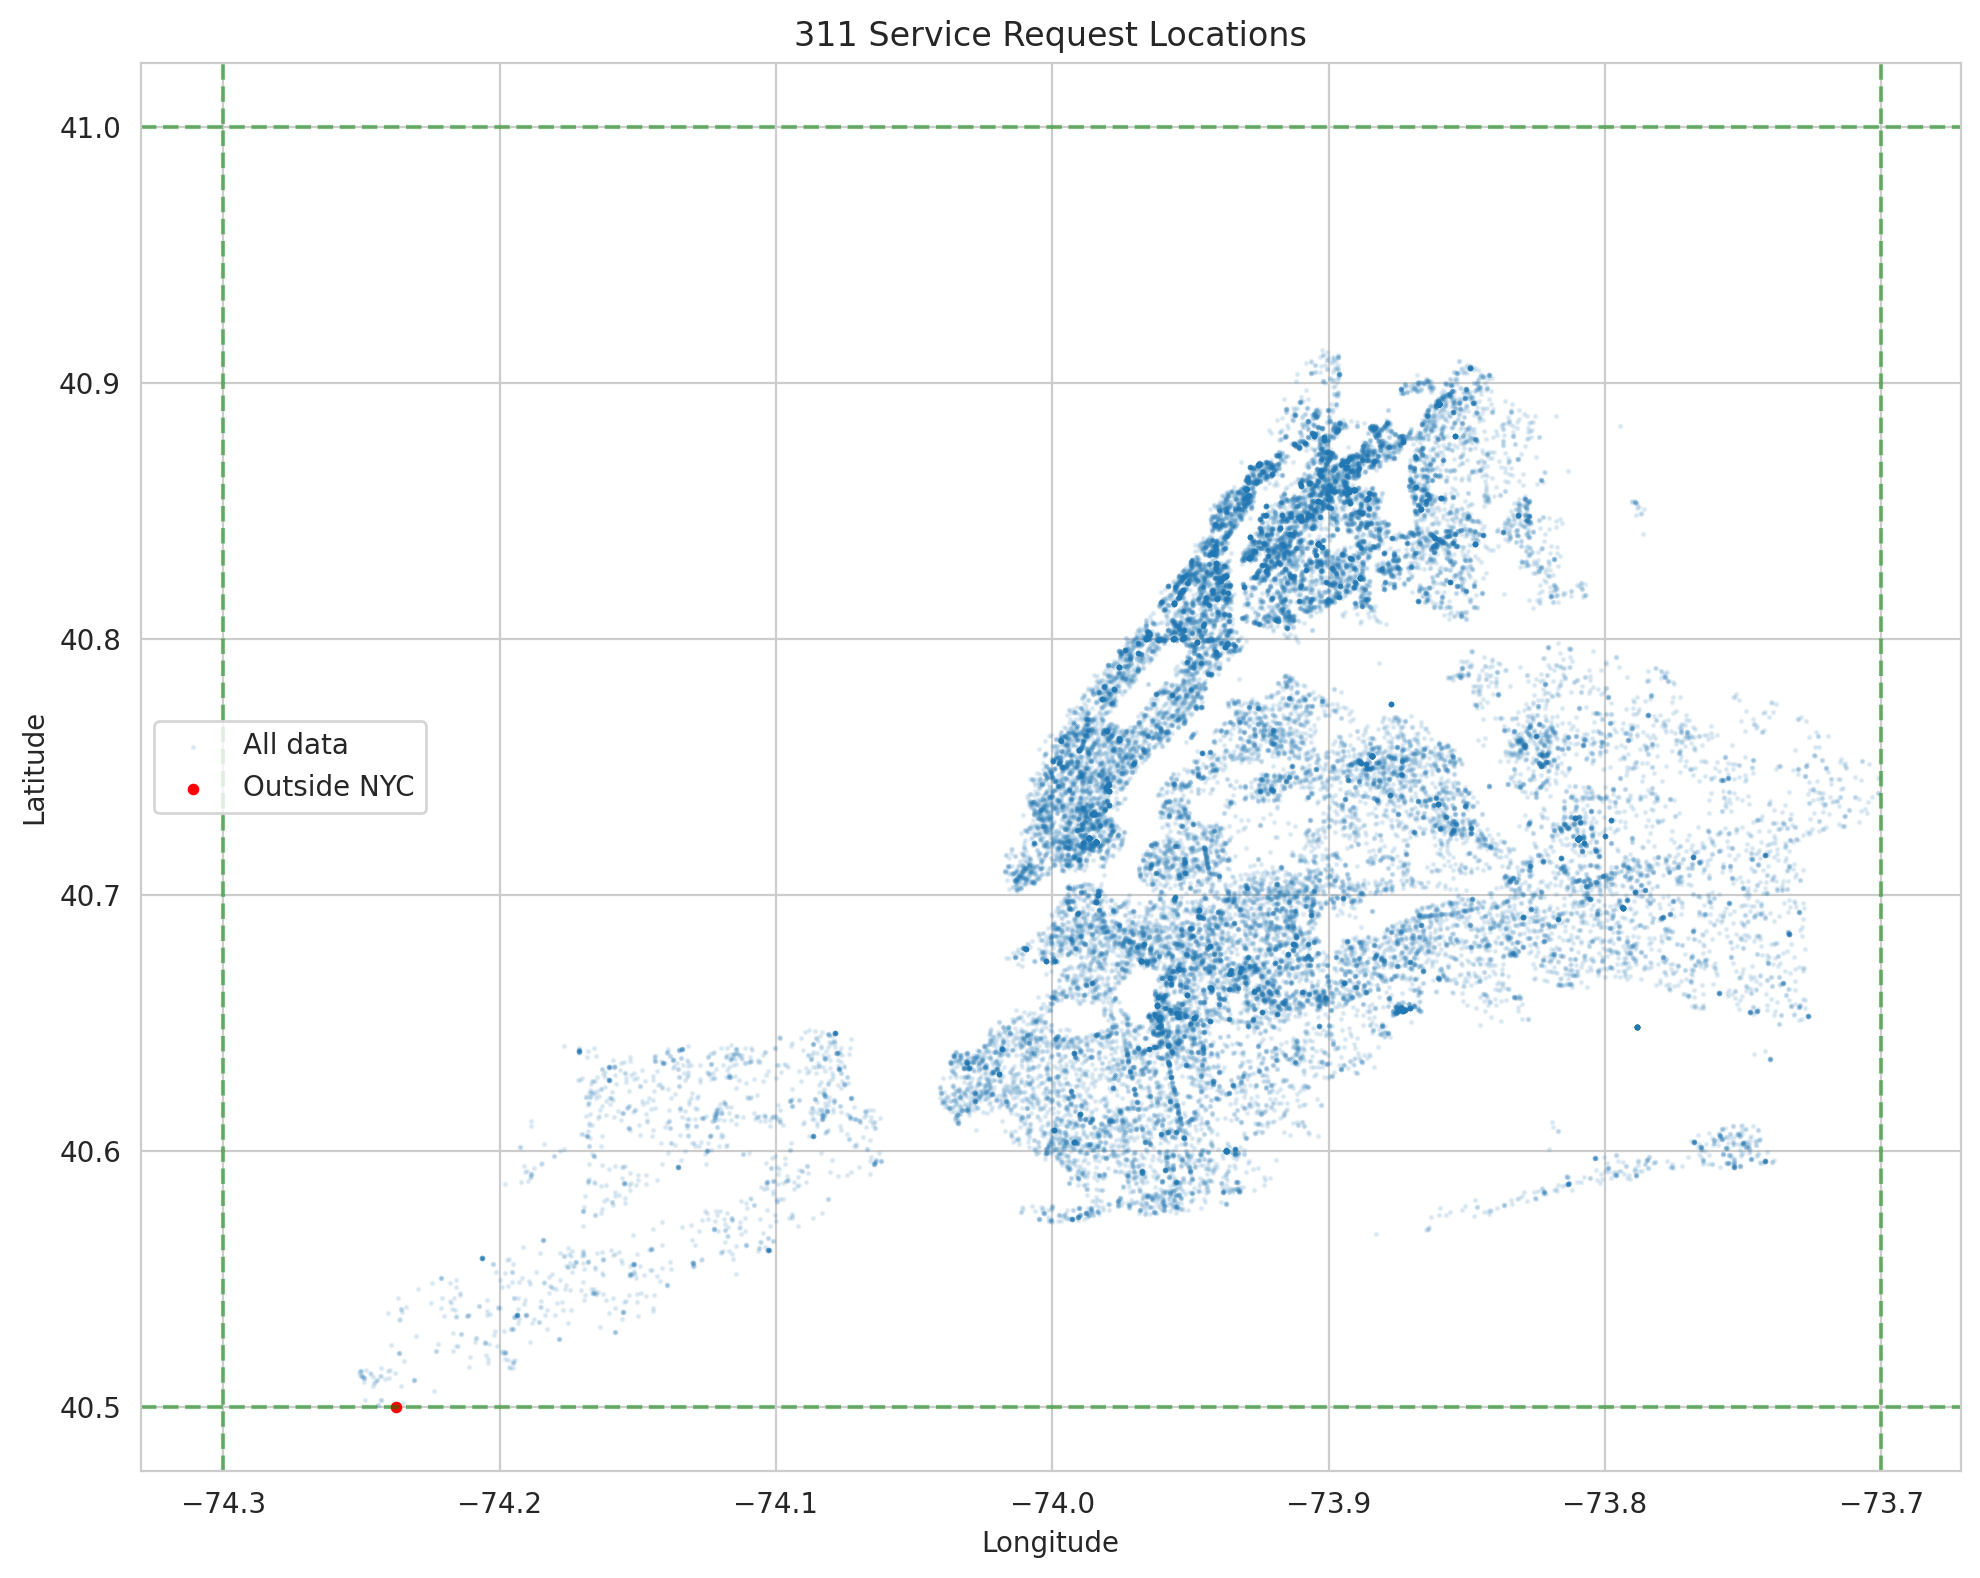

In [67]:
# =============================================================================
# SOLUTION: Activity 5 - Geographic Outliers
# =============================================================================

# 1. Check coordinate ranges
print("Latitude range:")
print(df['latitude'].describe())
print("\nLongitude range:")
print(df['longitude'].describe())

# 2. Define NYC bounds
nyc_lat_min, nyc_lat_max = 40.5, 41.0
nyc_lon_min, nyc_lon_max = -74.3, -73.7

# 3. Find outliers
outside_nyc = df[
    (df['latitude'].notna()) &
    (
        (df['latitude'] < nyc_lat_min) |
        (df['latitude'] > nyc_lat_max) |
        (df['longitude'] < nyc_lon_min) |
        (df['longitude'] > nyc_lon_max)
    )
]
print(f"\nRecords outside NYC bounds: {len(outside_nyc)}")

# 4. Visualize
plt.figure(figsize=(10, 8))

# Plot all points
plt.scatter(
    df['longitude'],
    df['latitude'],
    alpha=0.1,
    s=1,
    label='All data'
)

# Highlight outliers
plt.scatter(
    outside_nyc['longitude'],
    outside_nyc['latitude'],
    color='red',
    s=10,
    label='Outside NYC'
)

# Draw NYC bounds
plt.axhline(y=nyc_lat_min, color='green', linestyle='--', alpha=0.5)
plt.axhline(y=nyc_lat_max, color='green', linestyle='--', alpha=0.5)
plt.axvline(x=nyc_lon_min, color='green', linestyle='--', alpha=0.5)
plt.axvline(x=nyc_lon_max, color='green', linestyle='--', alpha=0.5)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('311 Service Request Locations')
plt.legend()
plt.tight_layout()

---

## Summary: Data Cleaning Checklist

### Diagnosis
```python
df.shape                    # Dimensions
df.info()                   # Types and non-null counts
df.isna().sum()             # Missing values
df.duplicated().sum()       # Duplicates
df['col'].value_counts()    # Distribution
```

### Missing Data
```python
df.dropna()                          # Drop rows with any missing
df.dropna(subset=['col'])            # Drop if specific col is missing
df['col'].fillna(value)              # Fill with constant
df['col'].fillna(df['col'].mean())   # Fill with mean
df['col'].fillna(df['col'].median()) # Fill with median
df['col'].ffill()                    # Forward fill
```

### Text Cleaning
```python
df['col'].str.strip()               # Remove whitespace
df['col'].str.lower()               # Lowercase
df['col'].str.upper()               # Uppercase
df['col'].str.title()               # Title case
df['col'].str.replace('a', 'b')     # Replace
df['col'].str.contains('pattern')   # Search
df['col'].str.split(' ')            # Split
```

### Type Conversions
```python
pd.to_datetime(df['col'])           # Convert to datetime
pd.to_numeric(df['col'], errors='coerce')  # Convert to number
df['col'].astype('category')        # Convert to category
df['col'].astype(str)               # Convert to string
```

### Outliers
```python
# IQR method
Q1, Q3 = df['col'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

# Filter or cap
df[df['col'].between(lower, upper)]  # Remove
df['col'].clip(lower, upper)         # Cap
```

### Best Practices
1. **Always work on a copy**: `df_clean = df.copy()`
2. **Document your steps**: Use comments or a cleaning function
3. **Validate after cleaning**: Check that your data makes sense
4. **Be conservative**: When in doubt, keep the data and flag it